In [1]:
import zipfile
import os

# Define the path to your zip file
zip_file_path = '/content/PotatoDiseaseProject.zip'

# Define the directory where you want to extract the contents
extract_dir = '/content/PotatoDiseaseProject'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully!")

# List the contents of the extracted directory to verify
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


'/content/PotatoDiseaseProject.zip' unzipped to '/content/PotatoDiseaseProject' successfully!
Contents of the extracted directory:
PotatoDiseaseProject/
    PotatoDiseaseProject/
        Potatos/
            Potato___Early_blight/
                caf7512b-4e4e-44fc-ae7d-8544168cf903___RS_Early.B 7120.JPG
                0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG
                9fa151cd-43d7-42e1-9235-72f58c584a4b___RS_Early.B 8581.JPG
                07d777f8-2c5a-48da-935e-f17c572b1e6e___RS_Early.B 7880.JPG
                b1b55149-b5bc-460e-87af-a745fb01855d___RS_Early.B 7477.JPG
                c71ad6f9-6258-4602-84dc-ecf75296672c___RS_Early.B 7525.JPG
                63f59fdf-973f-4d9e-a1ac-4a21cdfb9393___RS_Early.B 8794.JPG
                7a8f295d-dc08-4a25-ba7a-28995729b6b6___RS_Early.B 8243.JPG
                2b6f9564-80a2-4db7-a5e6-72be5ef33a71___RS_Early.B 8009.JPG
                13ddd965-db42-4392-9798-fe0ba5ad7928___RS_Early.B 7631.JPG
                4a4

In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
# Define the base directory where your images are located
data_dir = '/content/PotatoDiseaseProject/PotatoDiseaseProject/Potatos'

# Define image parameters
image_size = (256, 256) # You can adjust this based on your model's input requirements
batch_size = 32 # You can adjust this for training performance

# Load the dataset using image_dataset_from_directory
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical', # or 'binary' or None, depending on your task
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=42 # for reproducibility
)

print(f"Successfully loaded dataset from: {data_dir}")
print(f"Number of batches: {len(dataset)}")

# Optionally, display the class names
class_names = dataset.class_names
print(f"Class names: {class_names}")


Found 2152 files belonging to 3 classes.
Successfully loaded dataset from: /content/PotatoDiseaseProject/PotatoDiseaseProject/Potatos
Number of batches: 68
Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [3]:
#this 68 are the no of batches
len(dataset)

68

In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

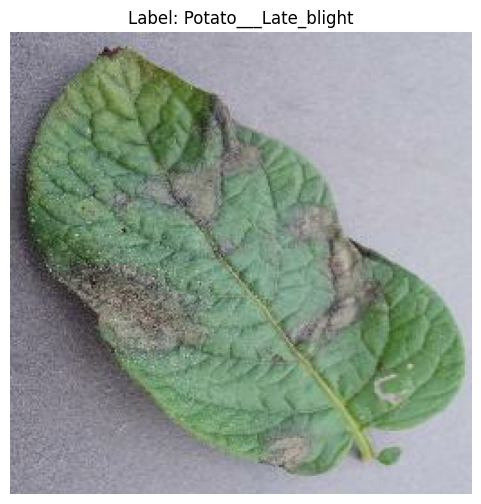

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get the first batch from the dataset
for images, labels in dataset.take(1):
    # Select the first image and its label from the batch
    first_image = images[0].numpy().astype("uint8")
    first_label = np.argmax(labels[0].numpy()) # Get the index of the highest probability class

    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(first_image)
    plt.title(f"Label: {class_names[first_label]}")
    plt.axis("off")
    plt.show()
    break # Exit after taking the first batch


In [6]:
for images, labels in dataset.take(1):
   # Select the first image and its label from the batch
    first_image = images[0].numpy()
    first_label = np.argmax(labels[0].numpy()) # Get the index of the highest probability class

print(first_image.shape)
print(first_label)

(256, 256, 3)
1


Spliting of Dataset 80% training and 20% --> 10%testing 10% validation

In [7]:
# Determine the number of batches for each split
total_batches = len(dataset)

train_batches = int(0.8 * total_batches)
val_batches = int(0.1 * total_batches)
# Ensure all remaining batches go to the test set to avoid data loss
test_batches = total_batches - train_batches - val_batches

print(f"Total batches: {total_batches}")
print(f"Training batches: {train_batches} ({train_batches / total_batches:.2%})")
print(f"Validation batches: {val_batches} ({val_batches / total_batches:.2%})")
print(f"Test batches: {test_batches} ({test_batches / total_batches:.2%})")

# Create the training dataset
train_ds = dataset.take(train_batches)

# Create the validation dataset
val_ds = dataset.skip(train_batches).take(val_batches)

# Create the test dataset
test_ds = dataset.skip(train_batches + val_batches).take(test_batches)

print("\nDataset splits created successfully.")


Total batches: 68
Training batches: 54 (79.41%)
Validation batches: 6 (8.82%)
Test batches: 8 (11.76%)

Dataset splits created successfully.


For better performance during training, it's recommended to use **cache**() and **prefetch**() methods on your dataset.

.**cache**() keeps the images in memory after the first epoch, reducing I/O operations and speeding up subsequent epochs.
.**prefetch**() overlaps data preprocessing and model execution, ensuring that the CPU is not bottlenecked waiting for data to be loaded. It fetches batches in the background while the current batch is being processed by the model.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Training, validation, and test datasets configured with cache and prefetch.")


Training, validation, and test datasets configured with cache and prefetch.


Now Data Preprocessing Since the mattrix values are between 0 to 256

In [9]:
#Scaling
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),
    layers.Rescaling(1.0 / 255),
])

In [10]:
#Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [11]:
input_tensor_shape = (image_size[0], image_size[1], 3) # Define the actual input shape with channels

model = models.Sequential([
    tf.keras.Input(shape=input_tensor_shape), # Explicitly define the input layer
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    batch_size=batch_size,
    validation_data=val_ds,
    epochs=3,
    verbose=1
)

Epoch 1/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - accuracy: 0.8438 - loss: 0.4244 - val_accuracy: 0.9115 - val_loss: 0.2227
Epoch 2/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 243s 5s/step - accuracy: 0.8808 - loss: 0.2908 - val_accuracy: 0.8802 - val_loss: 0.3795
Epoch 3/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 231s 4s/step - accuracy: 0.9091 - loss: 0.2443 - val_accuracy: 0.9219 - val_loss: 0.2567


In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9353 - loss: 0.2032
Test Loss: 0.2032
Test Accuracy: 0.9353


**Training History Visualization**

It's a good practice to visualize the training and validation accuracy and loss over epochs to understand model performance and detect issues like overfitting or underfitting. The history object returned by model.fit() contains this data.

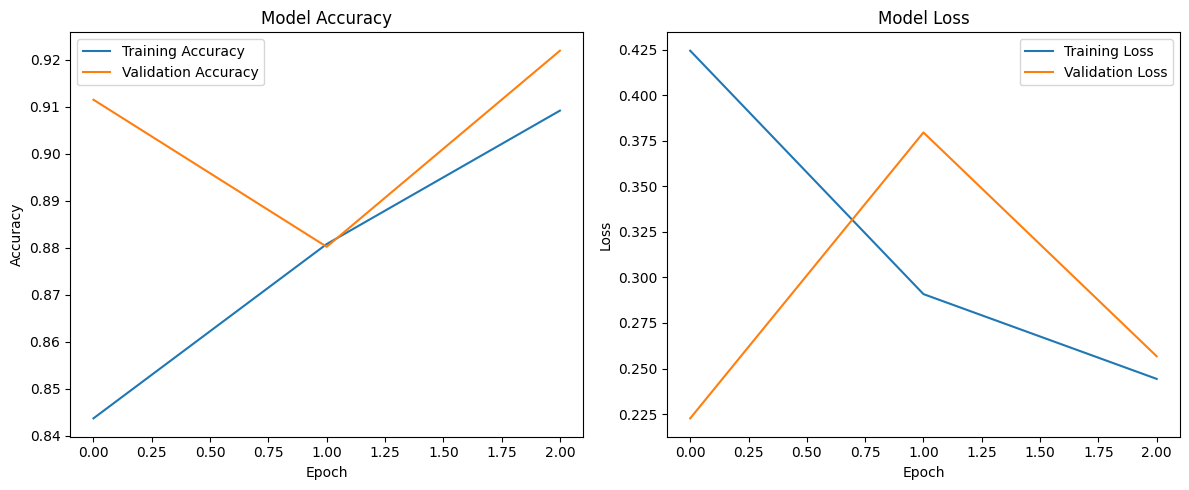

In [17]:
import matplotlib.pyplot as plt

epochs = range(len(history.history['accuracy']))

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Making Predictions**

Now, let's use the trained model to make predictions on a few samples from the test dataset. We'll pick a batch, display some images, and show what the model predicts for them.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


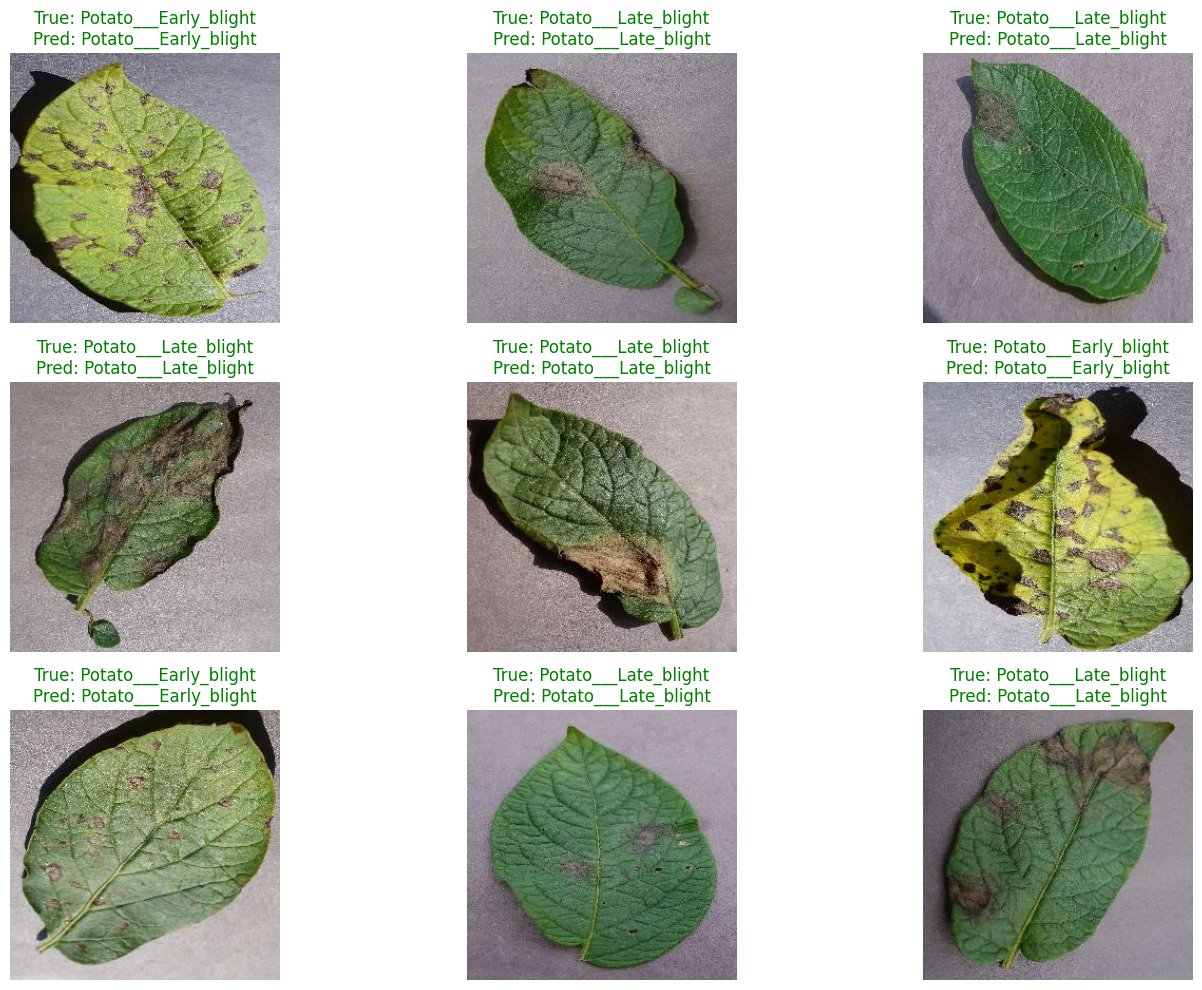

In [18]:
import numpy as np

# Get a batch of images and labels from the test dataset
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = np.argmax(labels.numpy(), axis=1)
    break

# Make predictions
predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

# Display some sample images with their true and predicted labels
plt.figure(figsize=(15, 10))
for i in range(min(9, len(sample_images))): # Display up to 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].astype("uint8"))
    true_label = class_names[sample_labels[i]]
    predicted_label = class_names[predicted_classes[i]]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
model.save('/content/potato_disease_model.keras')

In [20]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model(
    '/content/potato_disease_model.keras'
)

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

# Save TFLite model
with open('/content/potato_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model converted successfully!")

Saved artifact at '/tmp/tmpcs5i74_z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138914415561040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413249744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914678705040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413260880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914415908176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914415910672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413254736

In [21]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open('/content/potato_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model saved successfully!")

Saved artifact at '/tmp/tmp6wezamsk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138914415561040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413249744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914678705040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413260880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413251472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914415908176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914415910672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138914413254736

In [22]:
from google.colab import files

files.download('/content/potato_disease_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>